# Proyecto Final UD2
#### UD2. Aprendizaxe Supervisada
#### ML. Machine Learning
#### IES de Teis (Vigo) - Jorge Escolano González


**Features o Input variables:**

1 - age: edad numérica

2 - job : tipo de trabajo (puede tomar los valores: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')

3 - marital : estado civil (puede tomar los valores: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)

4 - education : nivel de estudios (puede tomar los valores: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')

5 - default: ya tiene un crédito solicitado por defecto? (puede tomar los valores: 'no','yes','unknown')

6 - housing: tiene hipoteca? (puede tomar los valores: 'no','yes','unknown')

7 - loan: tiene una cuenta personal? (puede tomar los valores: 'no','yes','unknown')

8 - contact: tipo de comunicación de contacto (puede tomar los valores: 'cellular','telephone')

9 - month: último mes de contacto (puede tomar los valores: 'jan', 'feb', 'mar', ..., 'nov', 'dec')

10 - day_of_week: último día de la semana en el que se le ha contactado (puede tomar los valores: 'mon','tue','wed','thu','fri')

11 - duration: duración del último contacto en segundos (numérico). Importante: este atributo afecta en gran medida a la salida ya que si duration es 0, entonces  la salida es 'no')

12 - campaign: número de veces que se le ha contactado durante la campaña a este cliente (numérico, incluye el último contacto)

13 - pdays: número de días que han pasado desde que el cliente fue contactado por última vez(numérico; 999 significa que no ha sido contactado anteriormente)

14 - previous: número de contactos anteriores a esta campaña a este cliente(numérico)

15 - poutcome: resultado de la última campaña de marketing (categorical: 'failure','nonexistent','success')

16 - emp.var.rate: employment variation rate - quarterly indicator (numérico)

17 - cons.price.idx: IPC - indicador mensual (numérico)

18 - cons.conf.idx: índice de confianza de los consumidores - indicador mensual (numérico)

19 - euribor3m: euribor tasa 3 meses - indicador diario (numérico)

20 - nr.employed: número de trabajadores - indicador en porciones  (numérico)

**Output variable (desired target):**

21 - y: Suscripción al crédito por parte del cliente? (binary: 'yes','no')



## 1. Importación de paquetes y dataset

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score,roc_curve, roc_auc_score,precision_recall_curve
from sklearn.ensemble import RandomForestClassifier




df_credit = pd.read_csv("credit-train.csv")

df_test = pd.read_csv("credit-test.csv")

## 2.EDA y Visual EDA

## 2.1 Estudio general del dataset

**En este apartado se realiza un estudio exploratorio inicial del dataset con el objetivo de tener una visión global de la estructura y características.**

Se empieza por mostrar las primeras 5 filas del dataset. Esto nos da una visión general de todas las variables y los valores que tienen.

In [3]:
df_credit.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


También se necesita saber el tamaño total del dataset mostrando el número de filas y columnas.

In [4]:
df_credit.shape

(41188, 21)

Se muestra de que tipo es cada variable para ver cuantas son númericas y categóricas.

In [5]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

##### **Análisis:** 
**Se observa que el dataset contiene datos de 41 mil individuos y 21 variables, de las cuales 20 son de entrada y 1 es la objetivo. La distribución de las variables de entrada es de 10 categóricas y 10 numéricas, la variable objetivo es númerica (0/1), al contener variables categóricas será necesario aplicar técnicas de preprocesado posteriormente en el apartado 3. También se observa que el dataset no contiene ningún valor nulo, pese a ello, contiene valores "unknown" que también habrá que tratar.**

## 2.2 Estudio de la variable objetivo.

**Se analiza la distribución de la variable objetivo para comprobar si existe desbalanceo entre las clases o valores que no correspondan.**

Con value_counts() se muestra el conteo de variables de "y".

In [6]:
df_credit["y"].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

Se saca la proporción el porcentaje normalizando el conteo.

In [7]:
df_credit['y'].value_counts(normalize=True) * 100


y
0    88.734583
1    11.265417
Name: proportion, dtype: float64

Utilizando un dataframe se puede estructurar el conteo y el porcentaje en una tabla para una mejor visualización.

In [8]:
resumen_target = pd.DataFrame({
    'conteo': df_credit['y'].value_counts(),
    'porcentaje': df_credit['y'].value_counts(normalize=True) * 100
})

resumen_target


,conteo,porcentaje
y,,
0,36548,88.734583
1,4640,11.265417


Se crea un gráfico de barras que muestre de forma visual la distribución de "y". En el gráfico de la izquierda en base al número de registros y en el de la derecha por porcentaje total.

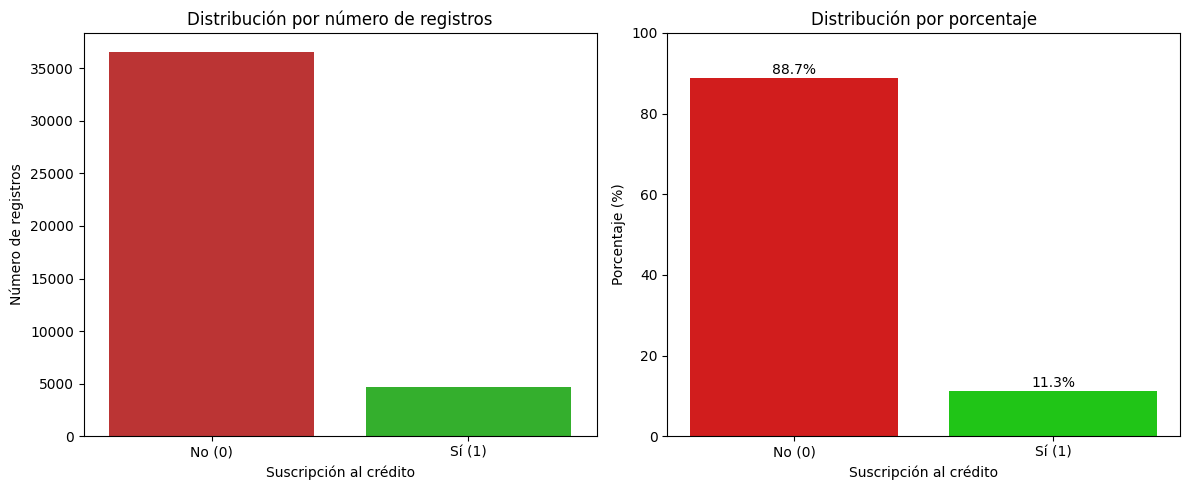

In [11]:
colors = ["#D11D1D", "#20C517"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sb.countplot(x='y', hue='y', data=df_credit, ax=axes[0], palette=colors, legend=False)

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No (0)', 'Sí (1)'])
axes[0].set_xlabel('Suscripción al crédito')
axes[0].set_ylabel('Número de registros')
axes[0].set_title('Distribución por número de registros')


porcentajes = df_credit['y'].value_counts(normalize=True) * 100

axes[1].bar(porcentajes.index, porcentajes.values, color=colors)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No (0)', 'Sí (1)'])
axes[1].set_xlabel('Suscripción al crédito')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_title('Distribución por porcentaje')
axes[1].set_ylim(0, 100)

for i, v in enumerate(porcentajes.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()


##### **Análisis:** 
**Se observa que la variable objetivo presenta un gran desbalanceo de datos ya que, el ~89% son de individuos que no accedieron al crédito que son ~36500 individuos, mientras que, por otra parte, un ~11% son de individuos que si accedieron al crédito que son 4640.**

**Esto significa que casi 9 de cada 10 registros pertenecen al No (0), este desbalanceo puede provocar sesgos hacia la clase mayoritaria y dificultad para predecir correctamente la clase minoritaria.**

## 2.3 Estudio de variables numéricas.

**Se analizan las variables numéricas con el objetivo de ver la distribución y posibles relaciones entre ellas, lo cual es esencial para poder seleccionar las que son relevantes.**

Se utiliza el describe para mostrar valores estadísticos y se añaden algunos percentiles a mayores.

In [12]:
df_credit.describe(percentiles=[0.10,0.25,0.50,0.75,0.90]).T

,count,mean,std,min,10%,25%,50%,75%,90%,max
age,41188.0,40.024060,10.421250,17.000,28.000,32.000,38.000,47.000,55.000,98.000
duration,41188.0,258.285010,259.279249,0.000,59.000,102.000,180.000,319.000,551.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,1.000,2.000,3.000,5.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,0.000,1.000,7.000
emp_var_rate,41188.0,0.081886,1.570960,-3.400,-1.800,-1.800,1.100,1.400,1.400,1.400
cons_price_idx,41188.0,93.575664,0.578840,92.201,92.893,93.075,93.749,93.994,94.465,94.767
cons_conf_idx,41188.0,-40.502600,4.628198,-50.800,-46.200,-42.700,-41.800,-36.400,-36.100,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.046,1.344,4.857,4.961,4.964,5.045
nr_employed,41188.0,5167.035911,72.251528,4963.600,5076.200,5099.100,5191.000,5228.100,5228.100,5228.100


##### **Análisis:**

**En las estadísticas se observan algunos puntos importantes:**

- **duration** y **campaign**: Los valores máximos (4918 y 56) están muy lejos de la media (258 y 2.56) y del percentil 90 (551 y 5), lo que indica la presencia de **outliers** que afectan a la media.  
- **pdays**: La mayoría de los valores es 999, lo que significa que el cliente no ha sido contactado previamente. Este valor distorsiona las estadísticas de la variable y requerirá tratamiento.  
- **previous**: Con una media de 0.17, indica que la gran mayoría de los clientes no ha sido contactada anteriormente.  
- **emp_var_rate** y **cons_conf_idx**: Estas variables pueden tomar valores negativos, lo que hay que tener en cuenta al interpretarlas.



Con pairplot se muestran las relaciones a pares de todas las variables numéricas en gráficas de puntos.

In [ ]:
sb.pairplot(data=df_credit[df_credit.columns[0:]],diag_kws={'edgecolor':'k','bins':25},plot_kws={'edgecolor':'k'})
plt.show()

##### **Análisis:**

- **No se observa ninguna relación lineal clara entre ninguna pareja de variables. Esto podría implicar que modelos lineales tengan un rendimiento limitado.**
- **Entre las variables existen grandes diferencias de escala, lo que da como resultado estructuras de puntos muy dispersas. Esto hace necesario un escalado.**
- **Se observan estructuras de bandas horizontales y verticales que se deben a las variables que presentan valores discretos como previous o emp_var_rate. Estas variables son indicadores económicos que fluctúan por períodos.**
- **En las variables age, duration y campaign se observa una nube de puntos con una alta densidad en rangos bajos y valores más dispersos en rangos altos. Esta distribución sugiere la presencia de outliers.**

Mediante un gráfico de densidad se puede analizar que variables tienen o no un impacto en el target

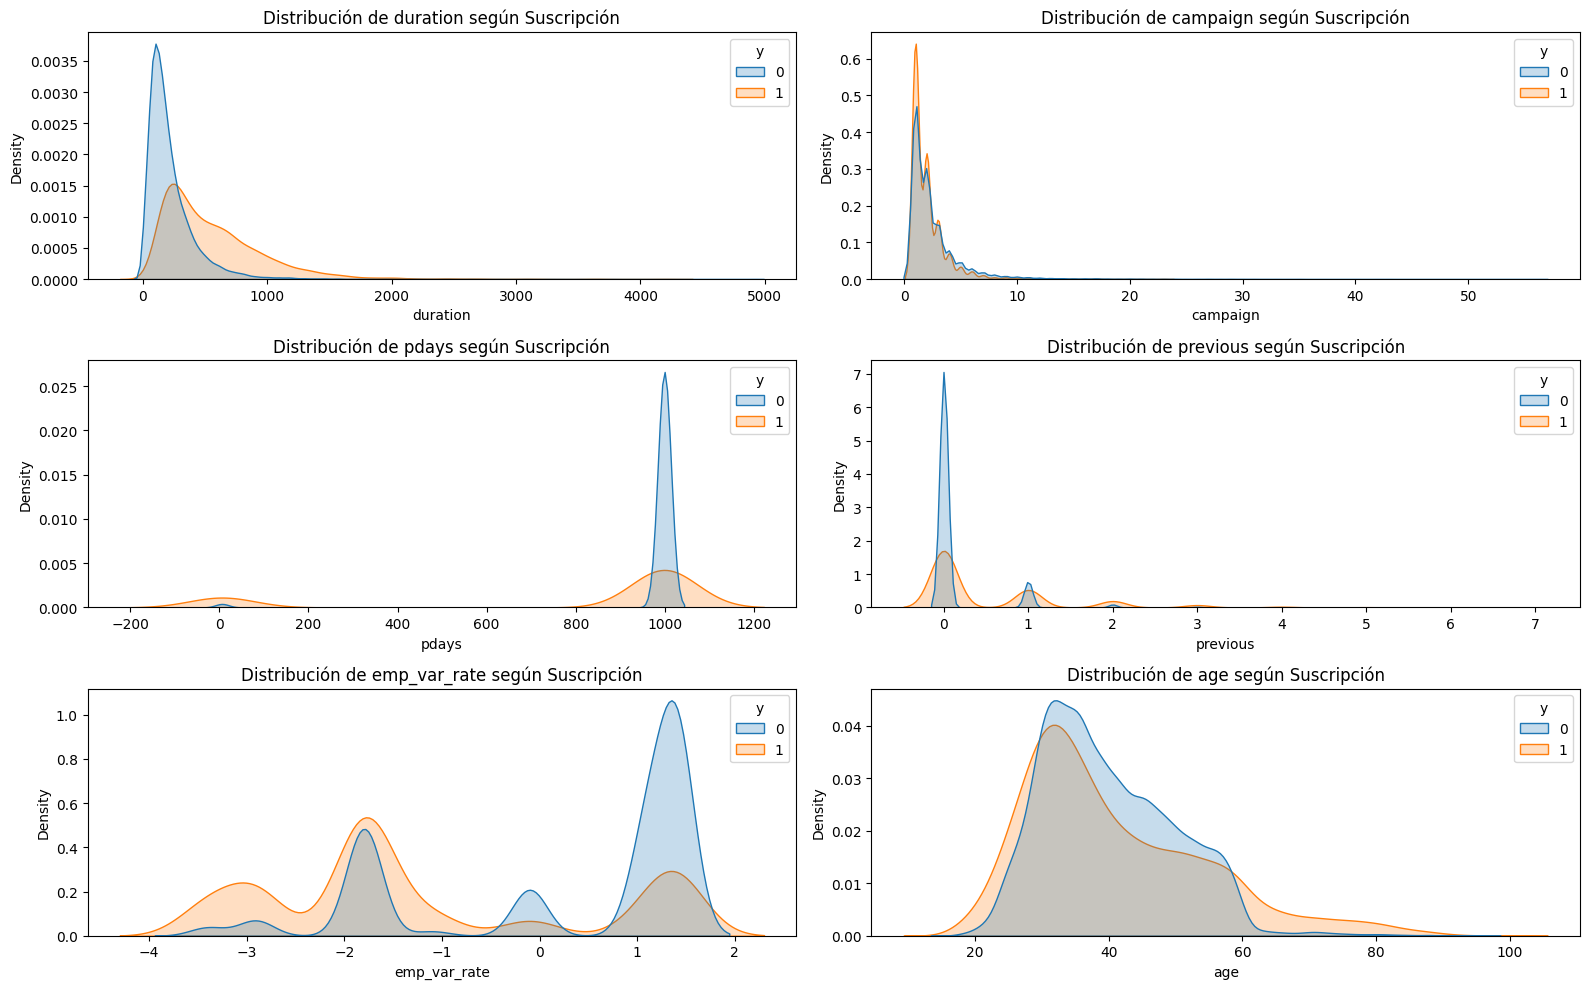

In [9]:
variables_clave = ['duration', 'campaign','pdays', 'previous','emp_var_rate','age']

plt.figure(figsize=(16, 10))

for i, var in enumerate(variables_clave):
    plt.subplot(3, 2, i+1)
    sb.kdeplot(data=df_credit, x=var, hue='y', fill=True, common_norm=False)
    plt.title(f'Distribución de {var} según Suscripción')

plt.tight_layout()
plt.show()

**Variables más influyentes:**
* **`duration`**: Se confirma como el diferenciador más claro. En los gráficos KDE, la curva de "yes" está desplazada hacia la derecha respecto a "no".
* **`euribor3m`**: Existe una relación inversa; a menor tasa de euribor, se observa visualmente una mayor densidad de respuestas positivas.

**Variables potencialmente irrelevantes:**
* **`age`**: Las distribuciones de "yes" y "no" están casi solapadas, lo que indica que por sí sola no ayuda mucho al modelo a decidir.
* **`campaign`**: Superados los 5-6 contactos, la probabilidad de éxito es marginal, lo que sugiere que el ruido aumenta tras demasiados intentos.

Para ver los valores outliers generamos un boxplot por variable

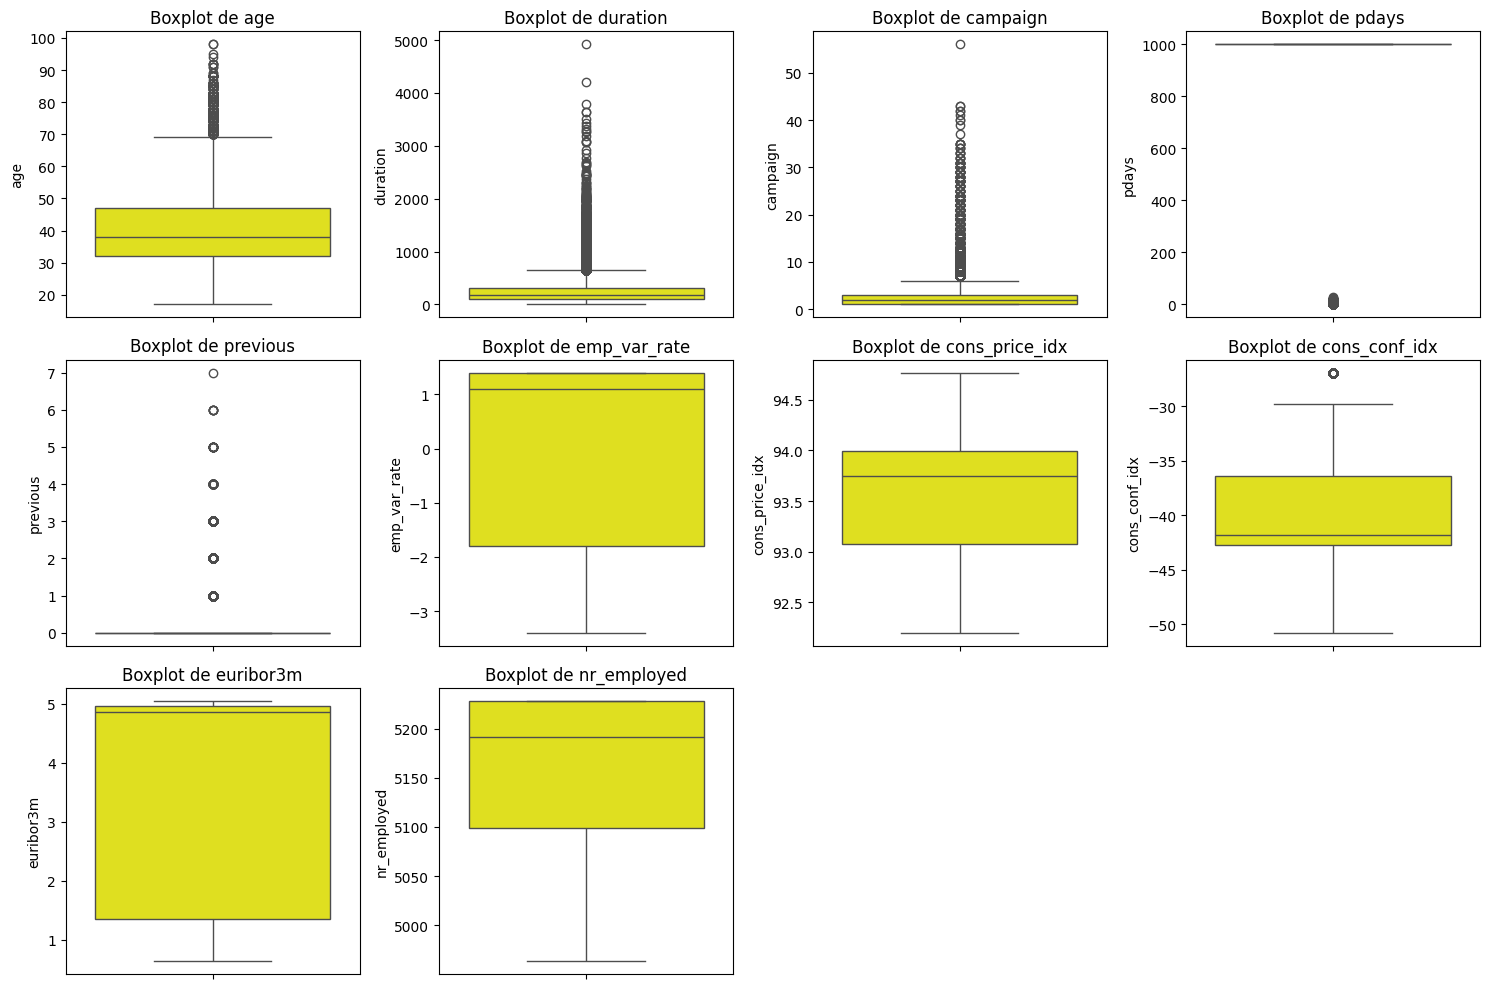

In [16]:
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 
            'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 4, i)
    sb.boxplot(y=df_credit[col], color='yellow')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

##### **Análisis**

- **En las variables `age`, `duration` y `campaign` se observa una gran cantidad de outliers en la parte superior, lo que indica distribuciones sesgadas con una alta concentración en valores bajos.**
- **La variable `pdays` muestra que casi la totalidad de los datos se sitúa en el valor máximo (999), lo que representa a clientes que no fueron contactados previamente, convirtiendo cualquier contacto real en un outlier inferior.**
- **En `previous` la mediana esta fija en el valor cero, indicando que la mayoría de los clientes no tuvo interacciones previas, en los valores superiores se encuentran outliers distribuidos de forma discreta.**
- **Las variables macroeconómicas como `emp_var_rate`, `euribor3m` y `nr_employed` muestran cajas muy amplias y medianas desplazadas hacia los valores superiores, reflejando periodos de estabilidad o tipos altos durante la captación de los datos.**

A través de una matriz de correlación se ve de forma numérica y visual las relaciones entre las variables y sobre todo con el target.

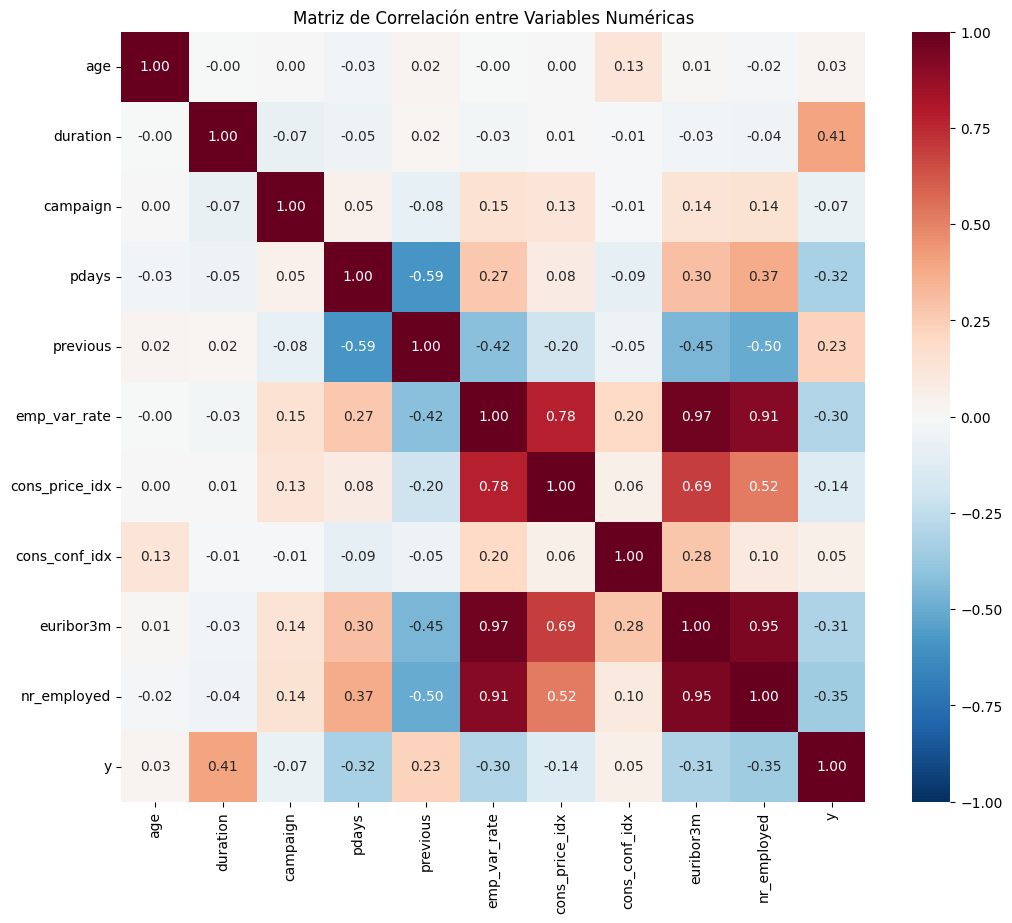

In [17]:
corr_matrix = df_credit.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sb.heatmap(corr_matrix, 
            annot=True,           
            fmt=".2f",            
            cmap='RdBu_r',        
            vmin=-1, vmax=1,      
            center=0)

plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

##### **Análisis:**

- **La variable con mayor correlación positiva con el éxito de la campaña (`y`) es `duration` (0.41). Esto confirma que el tiempo de conversación con el cliente es el factor determinante más influyente para conseguir la suscripción.**
- **Se observa una fuerte correlación positiva entre las variables macroeconómicas `emp_var_rate`, `euribor3m` y `nr_employed` (con valores entre 0.91 y 0.97). Esto indica una alta redundancia entre ellas, lo que podría causar multicolinealidad en modelos lineales.**
- **Existe una correlación negativa moderada entre el éxito de la campaña (`y`) y variables como `nr_employed` (-0.35), `pdays` (-0.32) y `euribor3m` (-0.31). Esto sugiere que en contextos de tipos de interés altos o tras periodos largos sin contacto, la probabilidad de éxito disminuye.**
- **La variable `pdays` tiene una correlación negativa significativa con `previous` (-0.59). Esto es lógico, ya que a medida que aumenta el número de contactos previos, disminuye el número de días desde el último contacto.**
- **La mayoría de las variables demográficas, como `age`, muestran una correlación casi nula con el resto de variables y con el objetivo final (0.03). Esto indica que la edad, por sí sola, no es un predictor directo del éxito sin interactuar con otros factores.**
- **El índice de precios al consumo (`cons_price_idx`) muestra una correlación alta con la tasa de variación del empleo (0.78) y el euribor (0.69), vinculando directamente el éxito de las campañas con el ciclo económico general.**

## 2.4 Estudio de variables categóricas.

**Se analizan las variables categóricas con el objetivo de ver sus valores y la relación con el target.**

Primeramente se realiza un value counts de todos los valores de cada variable y se muestra también en formato porcentaje

In [18]:
cat_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
            'contact', 'month', 'day_of_week', 'poutcome']

print("=== ANÁLISIS DE FRECUENCIAS (VALUE COUNTS) ===\n")

for var in cat_vars:
    print(f"Variable: {var.upper()}")
    counts = df_credit[var].value_counts()
    percentage = df_credit[var].value_counts(normalize=True) * 100
    
    tablas = pd.DataFrame({'Frecuencia': counts, 'Porcentaje (%)': percentage.round(2)})
    print(tablas)
    print("-" * 30)

=== ANÁLISIS DE FRECUENCIAS (VALUE COUNTS) ===

Variable: JOB
               Frecuencia  Porcentaje (%)
job                                      
admin.              10422           25.30
blue-collar          9254           22.47
technician           6743           16.37
services             3969            9.64
management           2924            7.10
retired              1720            4.18
entrepreneur         1456            3.54
self-employed        1421            3.45
housemaid            1060            2.57
unemployed           1014            2.46
student               875            2.12
unknown               330            0.80
------------------------------
Variable: MARITAL
          Frecuencia  Porcentaje (%)
marital                             
married        24928           60.52
single         11568           28.09
divorced        4612           11.20
unknown           80            0.19
------------------------------
Variable: EDUCATION
                     Frecuen

De forma gráfica se muestra en cada variable, el recuento de sus valores relacionandolo con el target, de forma que se pueden ver cuales tienen más impacto.

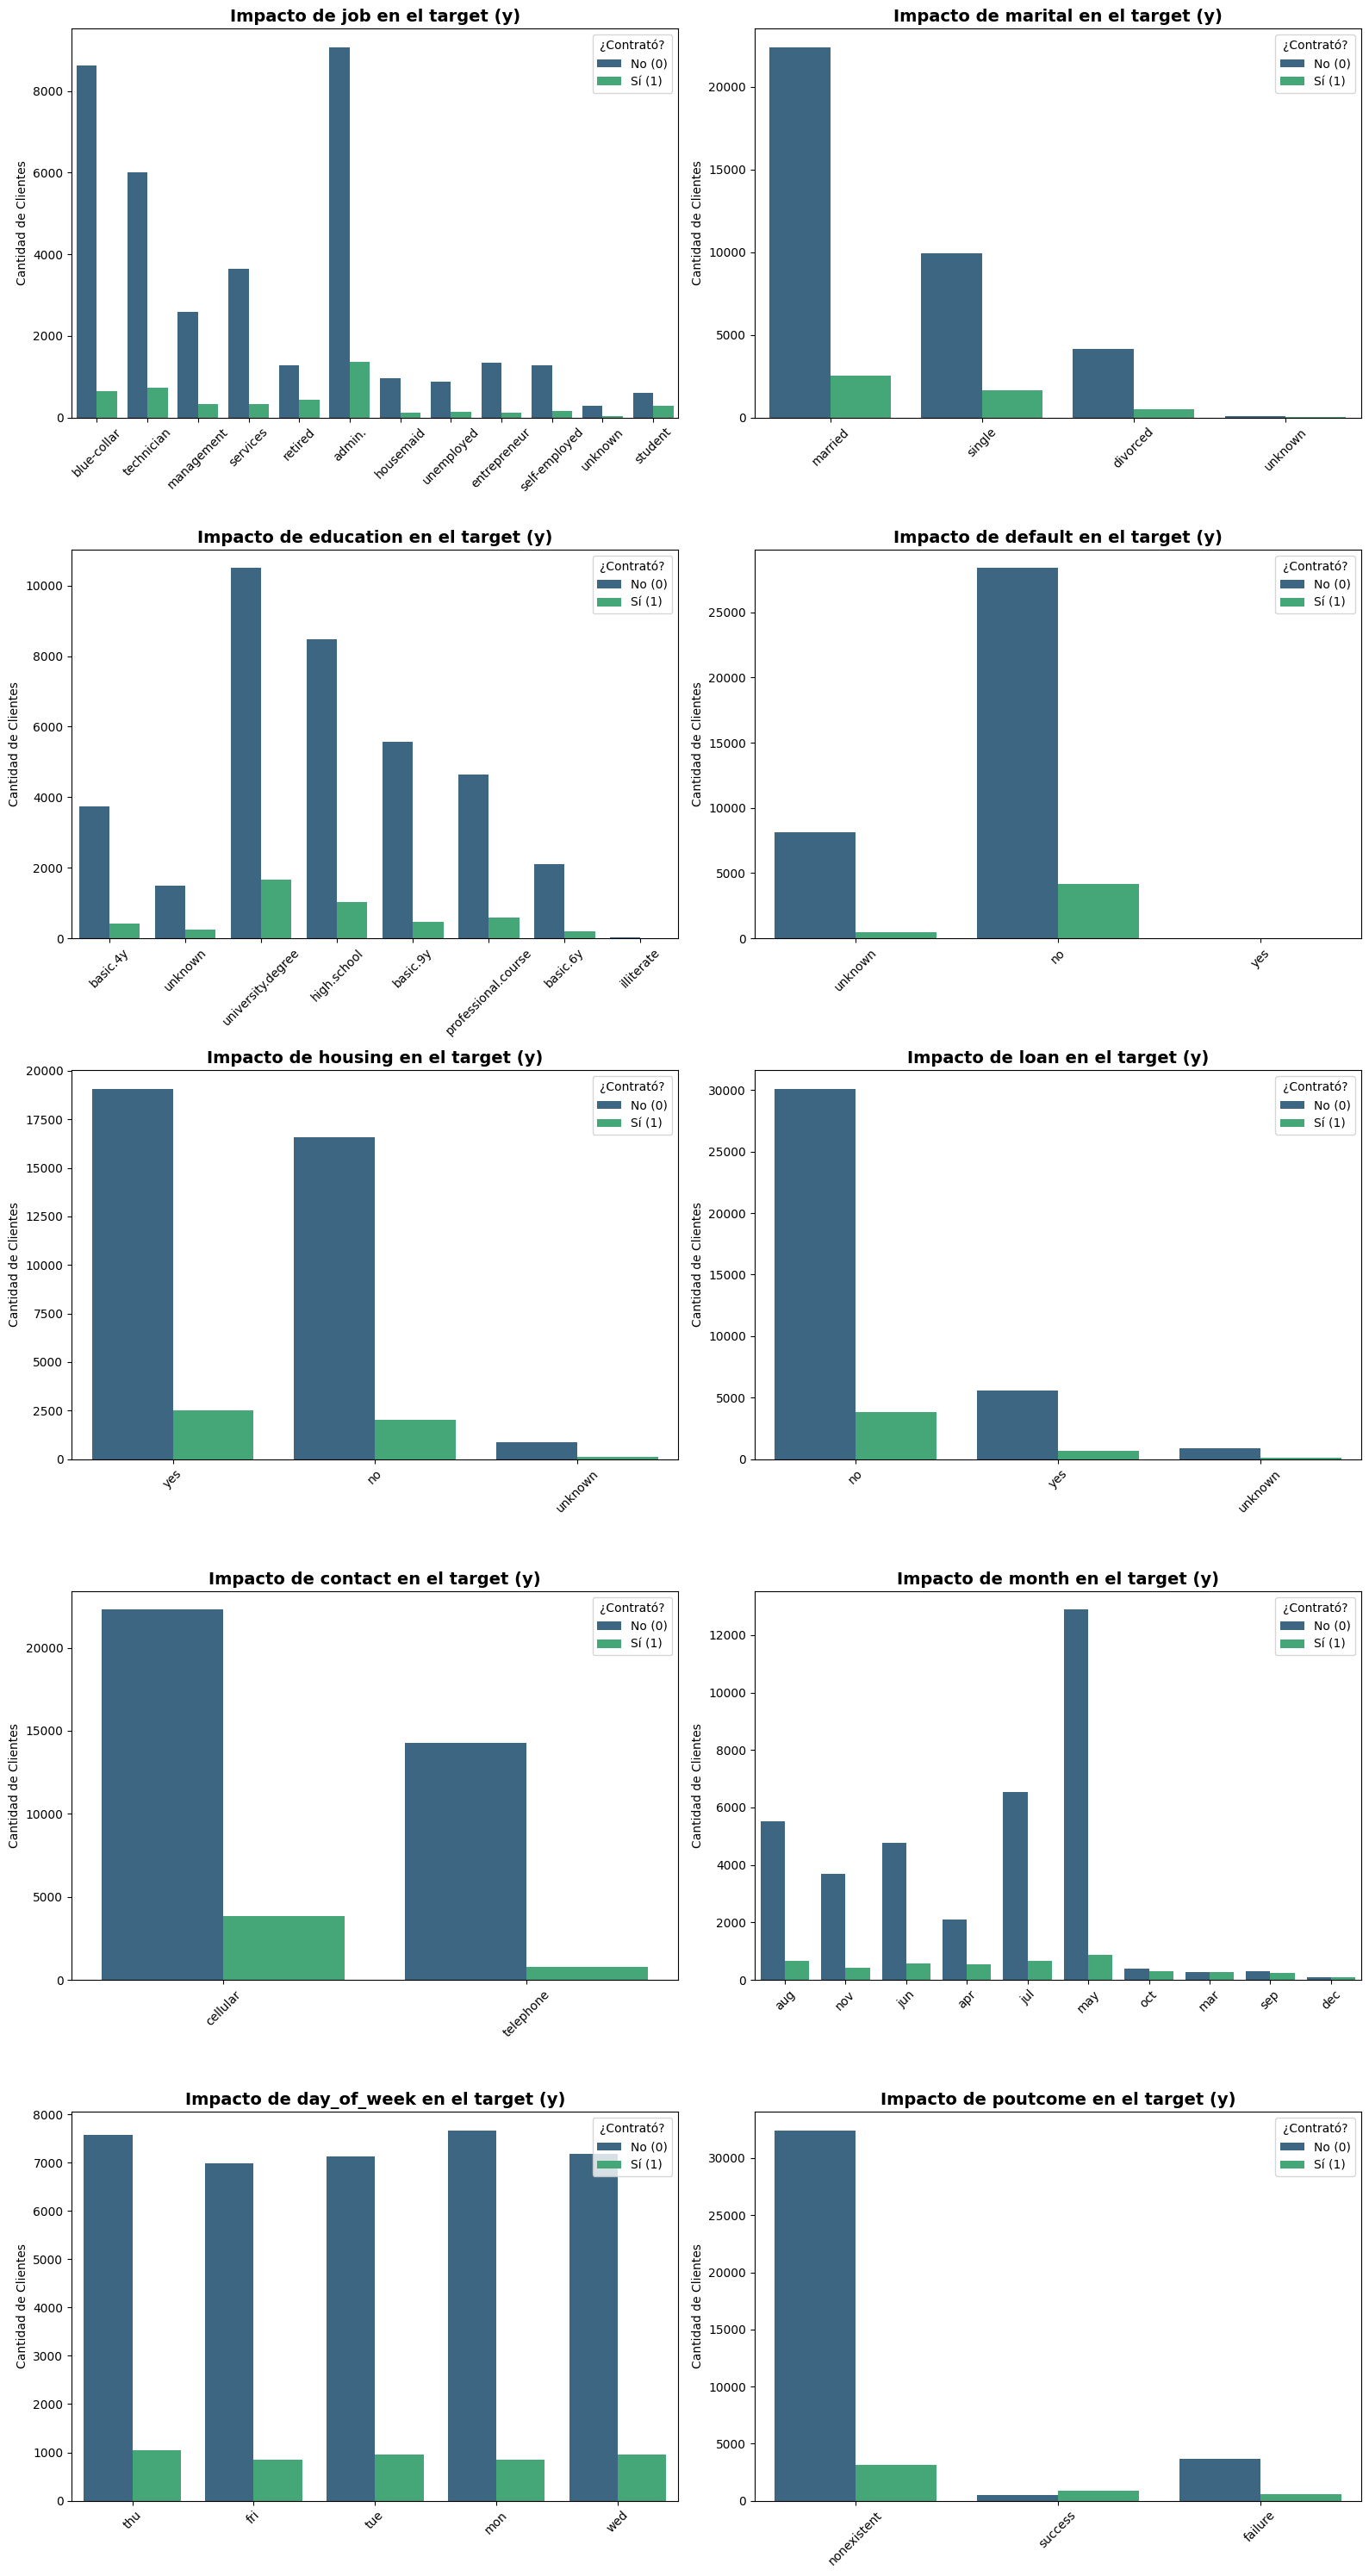

In [19]:
cat_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
            'contact', 'month', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 30))
axes = axes.flat

for i, var in enumerate(cat_vars):
    sb.countplot(x=var, data=df_credit, hue='y', ax=axes[i], palette='viridis')

    axes[i].set_title(f'Impacto de {var} en el target (y)', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de Clientes')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='¿Contrató?', labels=['No (0)', 'Sí (1)'])

plt.tight_layout()
plt.show()

##### **Análisis:**

- **Lo primero que salta a la vista es la gran diferencia de datos en `y` entre "no" y "si".**
- **Variables como `education`,`default`,`housing`,`month` y `poutcome` contienen gran desbalanceo de datos en sus valores.**
- **En `job` los perfiles de "admin", "blue-collar" y "technician" son los que más se contactan. Sin embargo, en proporción, los "retired" y "student" suelen tener una tasa de éxito proporcionalmente más alta, aunque su volumen total sea menor..**
- **En `contact` es mucho más exitoso "celullar" en comparación a "telephone".**
- **En `poutcome` cuando el resultado es "success" la proporción de éxito es más alta que de fracaso, lo que indica un valor predictivo clave.**
- **`day_of_week`: Los dias de la semana presentan prácticamente la misma distribución, por lo que seguramente sea una variable prescindible.**
- **`default` apenas contiene 3 valores de "yes", esto presenta un gran problema ya que apenas podemos obtener información.**

Se muestra de forma concreta las variables `day_of_week`,`month` y `education` para ver el porcentaje de exito de cada valor, con el objetivo de analizar si contiene valores que no aporten al modelo.

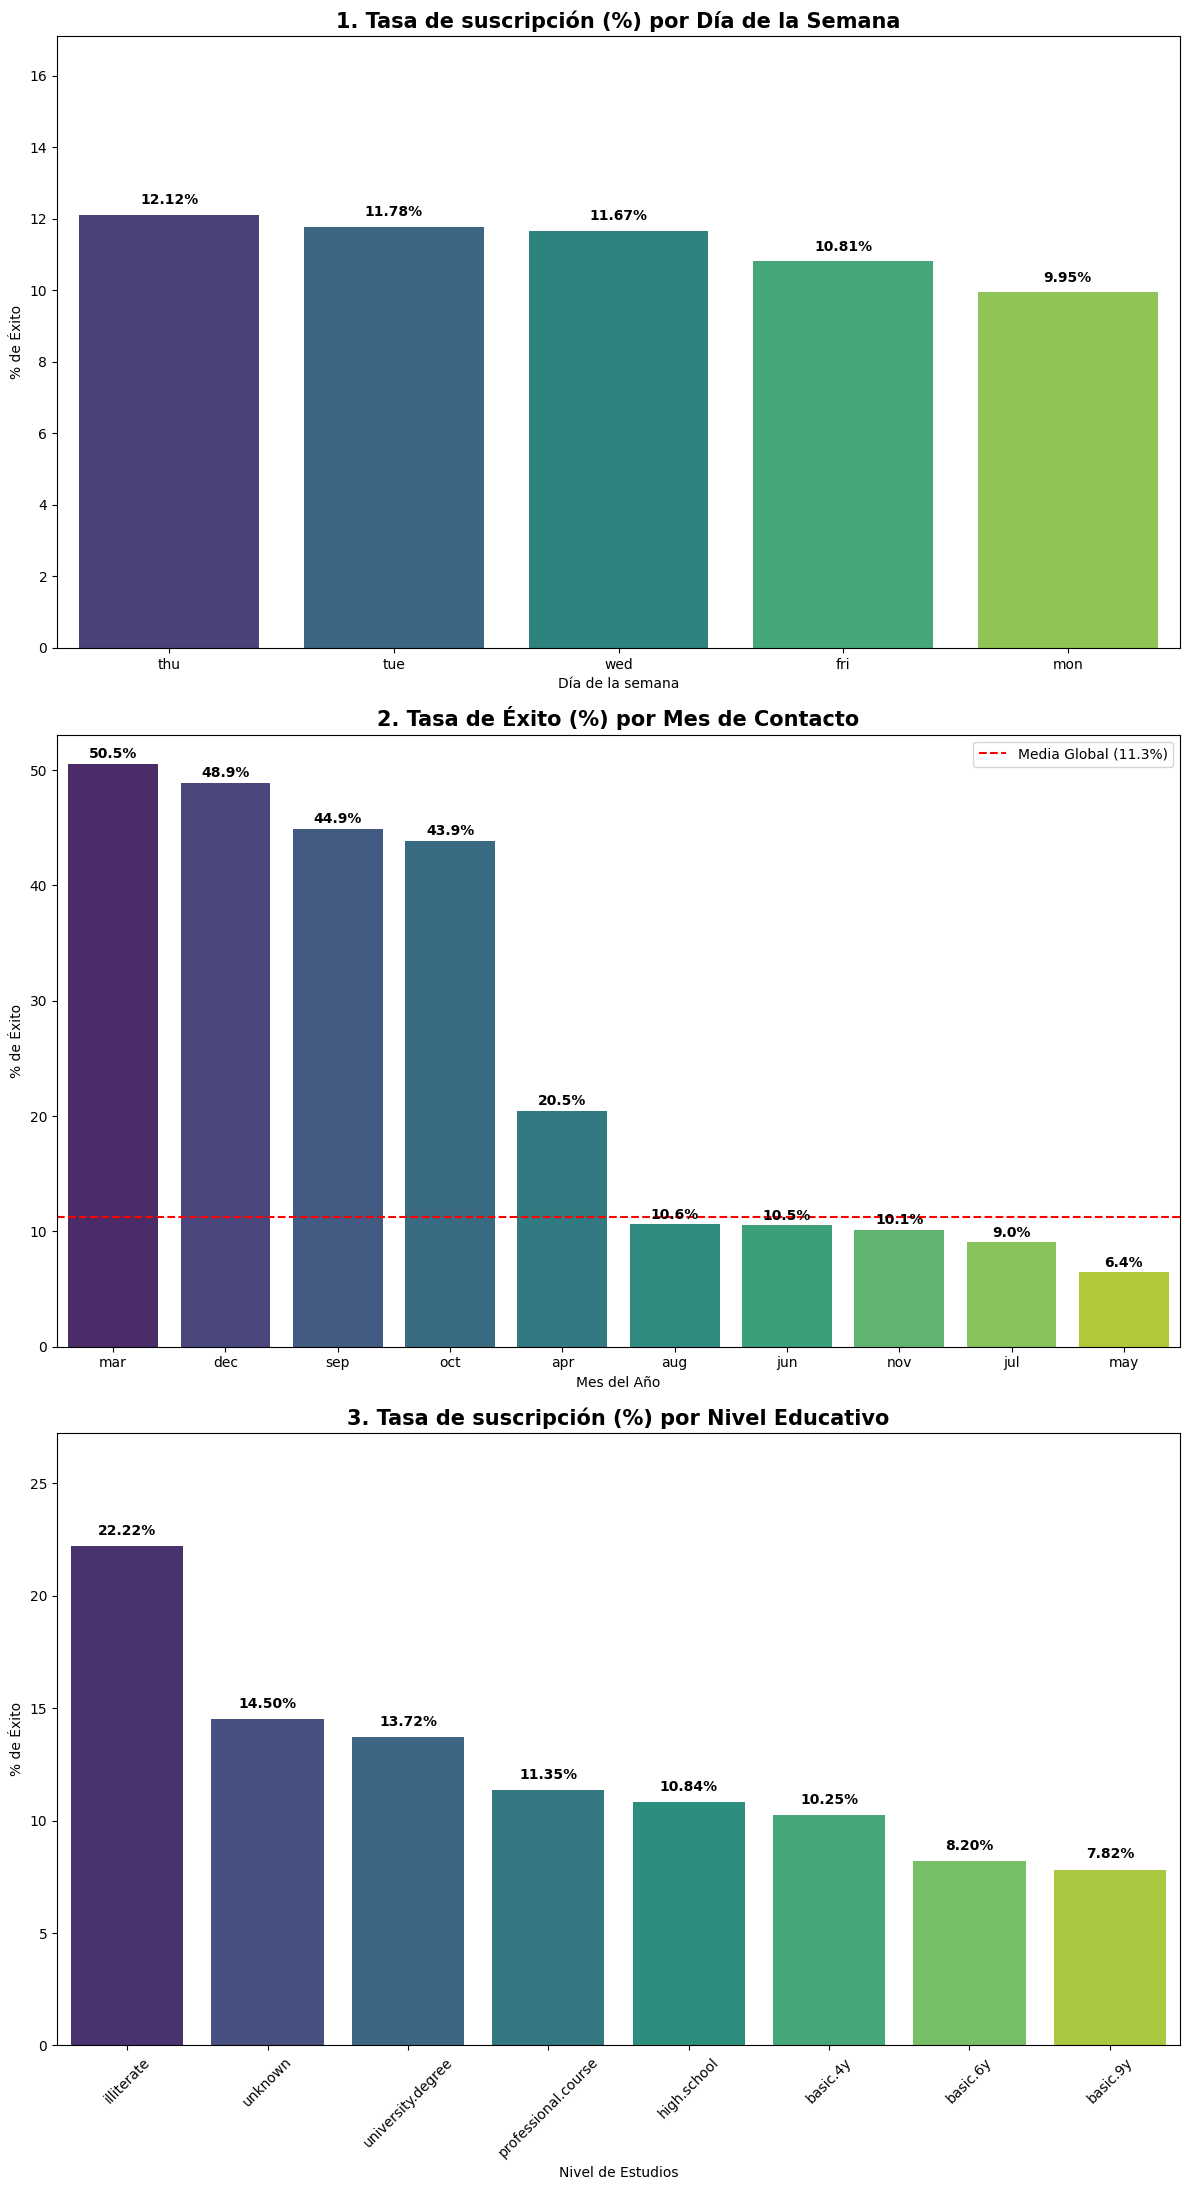

In [20]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 22))

# --- 1. GRÁFICO: Tasa de éxito por DÍA DE LA SEMANA
day_stats = (df_credit.groupby('day_of_week')['y'].value_counts(normalize=True).unstack() * 100)[1].sort_values(ascending=False)
sb.barplot(x=day_stats.index, y=day_stats.values, palette='viridis', ax=axes[0], hue=day_stats.index, legend=False)

axes[0].set_title('1. Tasa de suscripción (%) por Día de la Semana', fontsize=15, fontweight='bold')
axes[0].set_ylabel('% de Éxito')
axes[0].set_xlabel('Día de la semana')
axes[0].set_ylim(0, day_stats.max() + 5)

for i, val in enumerate(day_stats.values):
    axes[0].text(i, val + 0.3, f'{val:.2f}%', ha='center', fontweight='bold')


# --- 2. GRÁFICO: Tasa de éxito por MES
month_stats = df_credit.groupby('month')['y'].mean().sort_values(ascending=False) * 100
sb.barplot(x=month_stats.index, y=month_stats.values, palette='viridis', ax=axes[1], hue=month_stats.index, legend=False)

axes[1].set_title('2. Tasa de Éxito (%) por Mes de Contacto', fontsize=15, fontweight='bold')
axes[1].set_ylabel('% de Éxito')
axes[1].set_xlabel('Mes del Año')

media_global = df_credit['y'].mean() * 100
axes[1].axhline(media_global, color='red', linestyle='--', label=f'Media Global ({media_global:.1f}%)')
axes[1].legend()

for i, val in enumerate(month_stats.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')


# --- 3. GRÁFICO: Tasa de éxito por NIVEL EDUCATIVO
edu_stats = (df_credit.groupby('education')['y'].value_counts(normalize=True).unstack() * 100)[1].sort_values(ascending=False)
sb.barplot(x=edu_stats.index, y=edu_stats.values, palette='viridis', ax=axes[2], hue=edu_stats.index, legend=False)

axes[2].set_title('3. Tasa de suscripción (%) por Nivel Educativo', fontsize=15, fontweight='bold')
axes[2].set_ylabel('% de Éxito')
axes[2].set_xlabel('Nivel de Estudios')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim(0, edu_stats.max() + 5)

for i, val in enumerate(edu_stats.values):
    axes[2].text(i, val + 0.5, f'{val:.2f}%', ha='center', fontweight='bold')


plt.tight_layout()
plt.show()

##### **Análisis:**

- **Los días de la semana, `day_of_week` tienen prácticamente un porcentaje de éxito idéntico, por lo que no es una variable que afecte directamente en el resultado del target.**
- **Los meses de marzo, diciembre, septiembre y octubre tienen un altisimo porcentaje de éxito en comparación al resto.**
- **En general cuanto mejor es el nivel de estudios mayor es el porcentaje de éxito**

## 2.5 Estudio de valores especiales

**Se analizan las variables que con tienen valores nulos, trampas o unknown**

Primero se muestra si hay valores nulos.

In [2]:
null_counts = df_credit.isna().sum()
print(null_counts)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64


Se realiza un conteo de valores unknown por variable y mostramos también en porcentaje

In [3]:
cat_cols = df_credit.select_dtypes(include=['object']).columns

unknown_stats = []
for col in cat_cols:
    count = (df_credit[col] == 'unknown').sum()
    percent = (count / len(df_credit)) * 100
    unknown_stats.append({'Variable': col, 'Conteo': count, 'Porcentaje (%)': round(percent, 2)})

df_unk = pd.DataFrame(unknown_stats).sort_values(by='Conteo', ascending=False)
print("Resumen de valores 'unknown' por variable:")
print(df_unk)

Resumen de valores 'unknown' por variable:
      Variable  Conteo  Porcentaje (%)
3      default    8597           20.87
2    education    1731            4.20
4      housing     990            2.40
5         loan     990            2.40
0          job     330            0.80
1      marital      80            0.19
6      contact       0            0.00
7        month       0            0.00
8  day_of_week       0            0.00
9     poutcome       0            0.00


C:\Users\jorge\AppData\Local\Temp\ipykernel_9976\1551289905.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_credit.select_dtypes(include=['object']).columns


Se busca en la variable `pdays` cuantos datos corresponden al valor "999" y cuantos no.

In [4]:
pdays_999 = (df_credit['pdays'] == 999).sum()
pdays_otros = (df_credit['pdays'] != 999).sum()
total = len(df_credit)

print(f"Clientes nunca contactados (999): {pdays_999} ({pdays_999/total:.2%})")
print(f"Clientes contactados anteriormente: {pdays_otros} ({pdays_otros/total:.2%})")

Clientes nunca contactados (999): 39673 (96.32%)
Clientes contactados anteriormente: 1515 (3.68%)


Se muestran estos valores relacionandolos con el target `y`, se utiliza una nueva columna de apoyo.

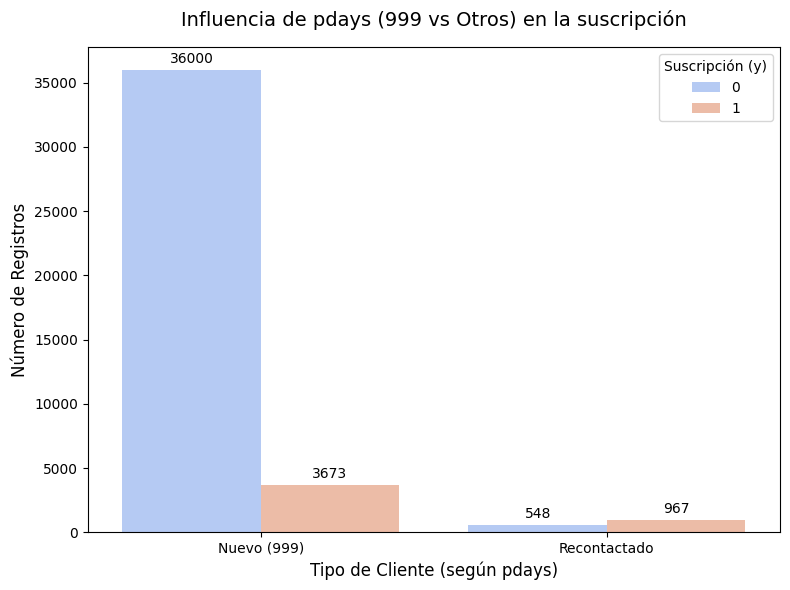

In [5]:
df_credit['tipo_contacto'] = df_credit['pdays'].apply(lambda x: 'Nuevo (999)' if x == 999 else 'Recontactado')

plt.figure(figsize=(8, 6))

ax = sb.countplot(x='tipo_contacto', hue='y', data=df_credit, palette='coolwarm')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Influencia de pdays (999 vs Otros) en la suscripción', fontsize=14, pad=15)
plt.xlabel('Tipo de Cliente (según pdays)', fontsize=12)
plt.ylabel('Número de Registros', fontsize=12)
plt.legend(title='Suscripción (y)')
plt.tight_layout()
plt.show()

* **Análisis:**

- **En la variable `pdays` más del 96% de los datos corresponden a "999", lo que equivale a no haber sido contactado y menos del 4% fueron contactados.**
- **En la gráfica se ve que tiene gran importancia haber sido contactado previamente para aceptar la suscripción. Es una variable importante pero al ser numérica y contener los "999" será necesario posteriormente generar la columna `tipo_contacto`.**

Se generan dos gráficos:
- El primero para ver la tasa de éxito en porcentaje en la variable `pdays`, entre clientes "nuevos" y "Recontactados"
- El segundo muestra cual es el mejor momento para recontactar al cliente.

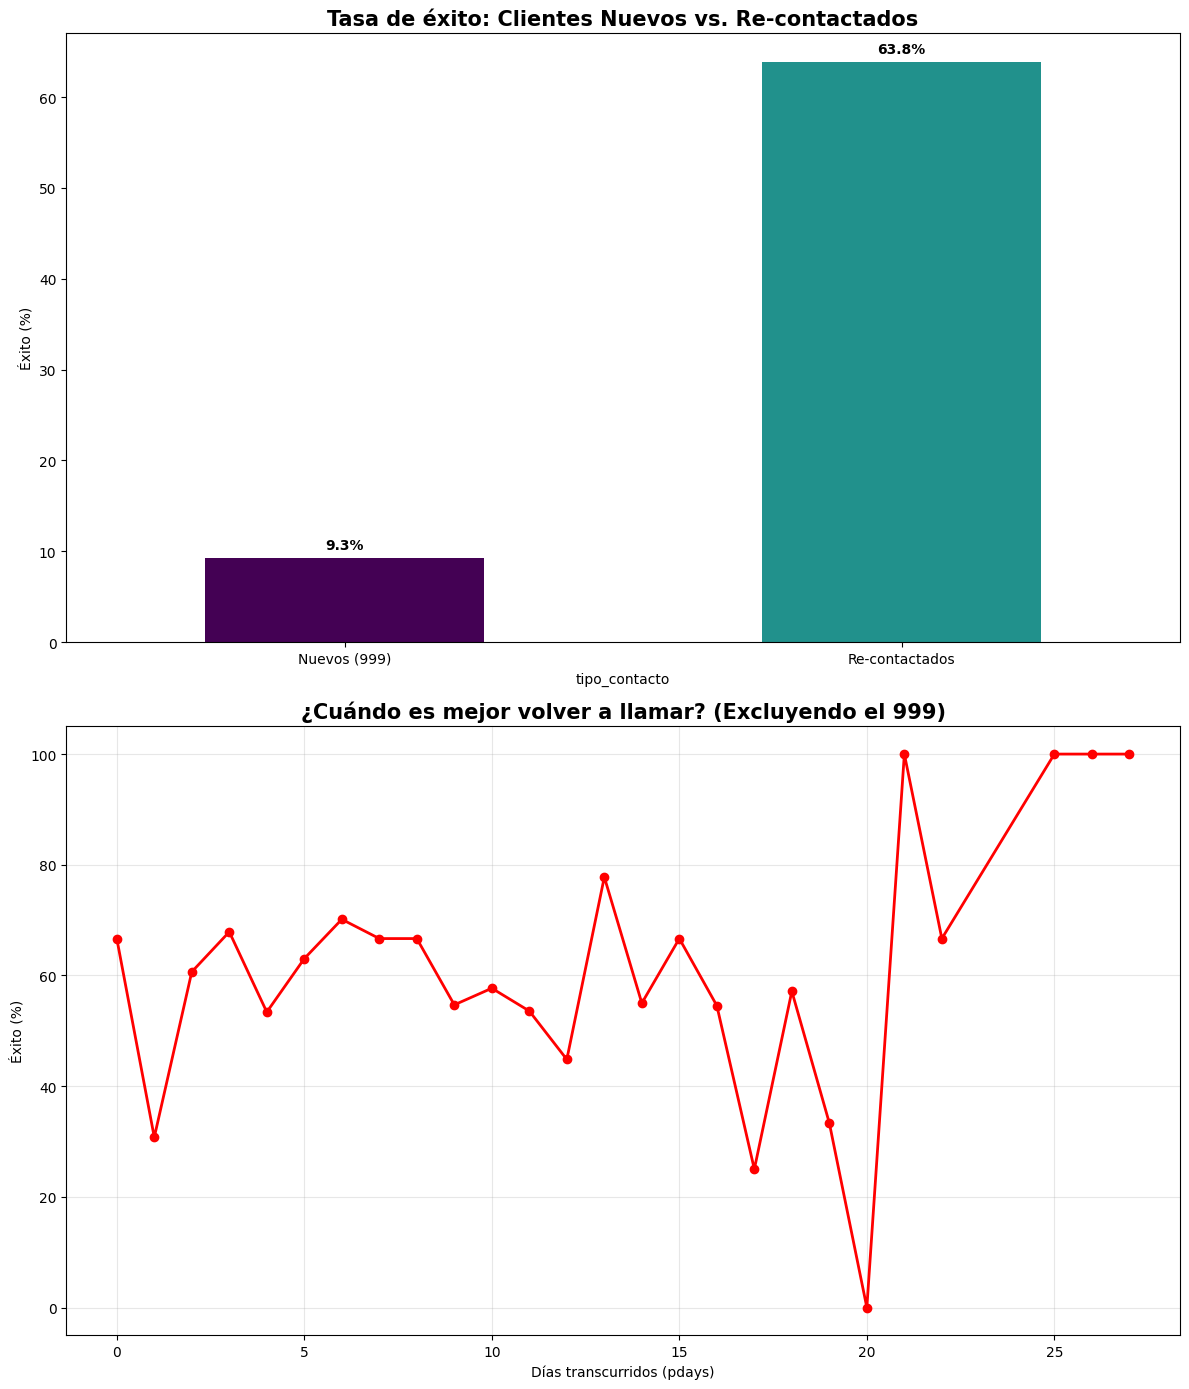

In [6]:
resumen_999 = df_credit.groupby('tipo_contacto')['y'].mean() * 100

df_contacted = df_credit[df_credit['pdays'] != 999]
tendencia_dias = df_contacted.groupby('pdays')['y'].mean() * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Gráfico 1:
resumen_999.plot(kind='bar', color=['#440154', '#21918c'], ax=axes[0])
axes[0].set_title('Tasa de éxito: Clientes Nuevos vs. Re-contactados', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Éxito (%)')
axes[0].set_xticklabels(['Nuevos (999)', 'Re-contactados'], rotation=0)

for i, val in enumerate(resumen_999):
    axes[0].text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')

# Gráfico 2:
tendencia_dias.plot(kind='line', marker='o', color='red', linewidth=2, ax=axes[1])
axes[1].set_title('¿Cuándo es mejor volver a llamar? (Excluyendo el 999)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Días transcurridos (pdays)')
axes[1].set_ylabel('Éxito (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* **Análisis:**

- **En el primer gráfico se muestra que apenas 1 de cada 10 clientes aceptan la suscripción cuando no hubo contacto previo, frente a cuando si hubo un contaco previo, donde la tasa de éxito es de más del 63%, es decir, 6 de cada 10 clientes.**
- **En la segunda gráfica se intenta averiguar, una vez sabiendo que es mejor cuando hubo contacto previo, en que momento es mejor volver a llamar al cliente. Se observa que están la mayoría de valores entre un 40% y 60% de éxito aproximadamente. El día número 20 tiene 0% pero algunos días posteriores como el 21, 25, 26 o 27 tienen un 100%. Hay que mostrar el número de muestras de cada día para ver si estos datos pueden servir.**

Se borra la columna auxiliar anterior.

In [7]:
df_credit.drop(columns=['tipo_contacto'], inplace=True)

Como se menciono antes, es importante contrastar los datos del segundo gráfico anterior porque la cantidad de datos en cada dia transcurrido del 0 al 27 no es equitativo, y podría ser engañoso.

C:\Users\jorge\AppData\Local\Temp\ipykernel_9976\3205138828.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x='pdays', data=df_contacted, palette='viridis')


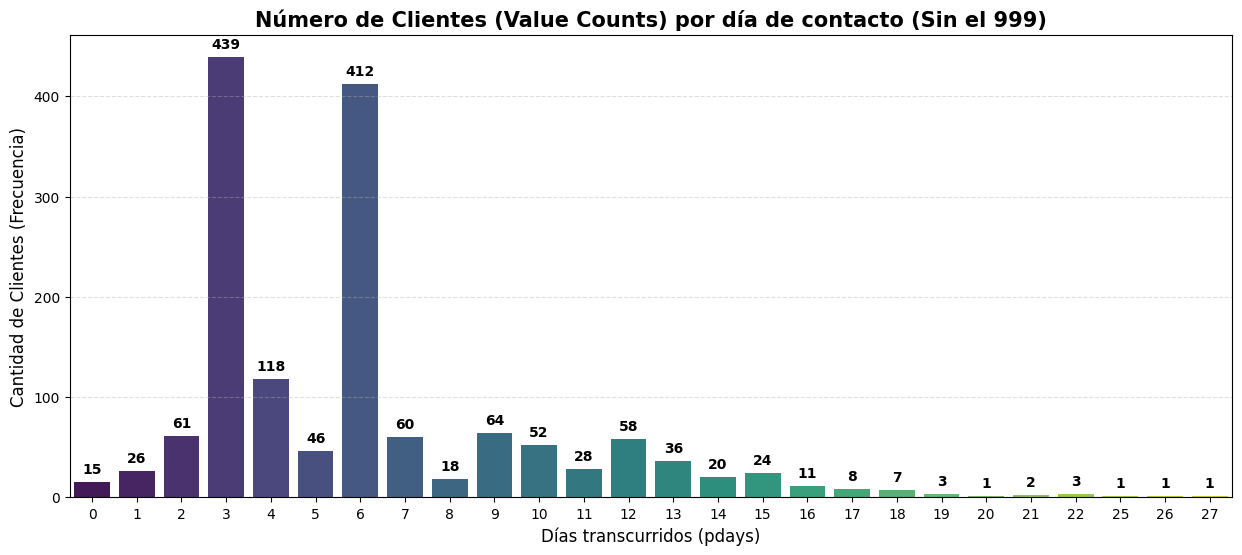

In [8]:
df_contacted = df_credit[df_credit['pdays'] != 999].copy()

plt.figure(figsize=(15, 6))

ax = sb.countplot(x='pdays', data=df_contacted, palette='viridis')

plt.title('Número de Clientes (Value Counts) por día de contacto (Sin el 999)', fontsize=15, fontweight='bold')
plt.xlabel('Días transcurridos (pdays)', fontsize=12)
plt.ylabel('Cantidad de Clientes (Frecuencia)', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

**Vemos una distribución muy sesgada entre el valor 3 y 6, y ridiculamente pequeña en valores mayores a 18.**

## 2.6 Relación entre variables y la variable objetivo : Análisis

**En este apartado se analizan que variables son relevantes para el modelo.**

**Features o Input variables:**

- 1 `age`: Se vio anteriormente como la gente joven y la gente de mas de 60 años es más propensa a aceptar la suscripción.
- 2  `job`: Presenta variedad de trabajos y diferentes tasas de éxito, por lo que es muy relevante.
- 3  `marital`: A priori no es la variable más relevante pero se mantendrá para los modelos.
- 4  `education`: El nivel de estudios es un factor clave.
- 5  `default`: Indica si ya tiene un crédito solicitado, sin embargo, contiene los valores "unknown", "no" y "yes", este útlimo apenas tiene datos por lo que solo podemos saber si no tiene un crédito o no saber el dato. Es una columna a borrar por este motivo.
- 6  `housing`: Si el cliente tiene hipoteca o no, es relevante.
- 7  `loan`: Indica si se tiene una cuenta personal, es relevante.
- 8  `contact`: El método de contacto, si por celular o móvil, no es una variable clave pero se mantendrá.
- 9  `month`: Hay ciertos meses que reflejan un porcentaje de éxito muy alto, es una variable relevante.
- 10 `day_of_week`: Muy poco relevante, la tasa de éxito apenas varía entre los días de la semana
- 11 `duration`: Es importante, se ve que cuando la llamada traspasa un umbral de tiempo la probabilidad de fracaso baja mucho, sin embargo hay que tratarla ya que contiene gran cantidad de outliers en valores altos.
- 12 `campaign`: Muestra cuantas veces fue contactado el cliente durante la campaña, es relevante. 
- 13 `pdays`: Contiene el valor trampa de "999", es una variable clave que hay que tratar para poder obtener información valiosa.
- 14 `previous`: Es una variable que muestra cuantas veces fue contactado previo a la campaña actual, es muy relevante.
- 15 `poutcome`: Una de las variables que muestra mayor relevancia.
- 16 `emp.var.rate`, `euribor3m`, `nr_employed`: Estas tres variables en la matriz de correlacion daban valores por encima de 0.90, están las tres relacionadas con la macroeconomia por lo que quedarse con solo una puede ser la mejor opción.
- 17 `cons.price.idx`: Indica el IPC, es relevante.
- 18 `cons.conf.idx`: Es el índice de confianza de los consumidores, es relevante.

## 3. Preprocessing data


In [31]:
df_prep = df_credit.copy()
df_test_prep = df_test.copy()

# La duración tiene un sesgo positivo extremo; el logaritmo suaviza outliers.
df_prep['duration'] = np.log1p(df_prep['duration'])
df_test_prep['duration'] = np.log1p(df_test_prep['duration'])

# B) Creación de Feature: 'tipo_de_contacto'
# Simplificamos pdays (999 vs resto) en una variable binaria de alto impacto.
df_prep['tipo_de_contacto'] = (df_prep['pdays'] != 999).astype(int)
df_test_prep['tipo_de_contacto'] = (df_test_prep['pdays'] != 999).astype(int)

# C) Selección de características: Eliminacion de columnas, eliminamos tambien pdays ya que creamos la nueva columna en el anterior paso

df_prep = df_prep.drop(['day_of_week','emp_var_rate','nr_employed','default','pdays'], axis=1, errors='ignore')
df_test_prep = df_test_prep.drop(['day_of_week','emp_var_rate','nr_employed','default','pdays'], axis=1, errors='ignore')

- Realizamos una copia del dataset analizado para realizarle el preprocesado.
- Todos los pasos serán tambien realizados en el dataset de "credit-test.csv" para luego poder realizar las predicciones.
- **1** Se suaviza la variable `duration` porque anteriormente se vio que mostraba una distribución muy amplia donde la mayoria de llamadas eran de pocos segundos pero habia otras de más de 4000s, de esta forma "empujamos" los valores hacia el centro.
- **2** Se genera la columna `tipo_de_contacto` que es la que utilizamos anteriormente para mostrar en el Visual EDA. Es una variable binaria que simplifica la variable `pdays` de forma binaria donde "0" significa no contactado anteriormente (999) y "1" significa que si fue contactado anteriormente (cualquier valor != 999)
- **3** Borramos todas las columnas que se analizaron anteriormente y se consideraron no relevantes.

Aplicamos un one-hot encoding para transformar las columnas categóricas en binarias.

In [32]:
cat_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Aplicamos One-Hot Encoding con tipo entero
df_prep = pd.get_dummies(df_prep, columns=cat_cols, dtype=int)
df_test_prep = pd.get_dummies(df_test_prep, columns=cat_cols, dtype=int)

Aplicamos un standarScaler para escalar las variables numéricas.

In [33]:
scaler = StandardScaler()
num_cols = ['age', 'duration', 'campaign', 'previous', 'cons_price_idx', 'cons_conf_idx', 'euribor3m']

df_prep[num_cols] = scaler.fit_transform(df_prep[num_cols])
df_test_prep[num_cols] = scaler.fit_transform(df_test_prep[num_cols])

Se genera un gráfico que representa la fuerza y dirección de la relación lineal entre las features y el target.

C:\Users\jorge\AppData\Local\Temp\ipykernel_9976\3000425463.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.barplot(x=correlations.values, y=correlations.index, palette=colors)


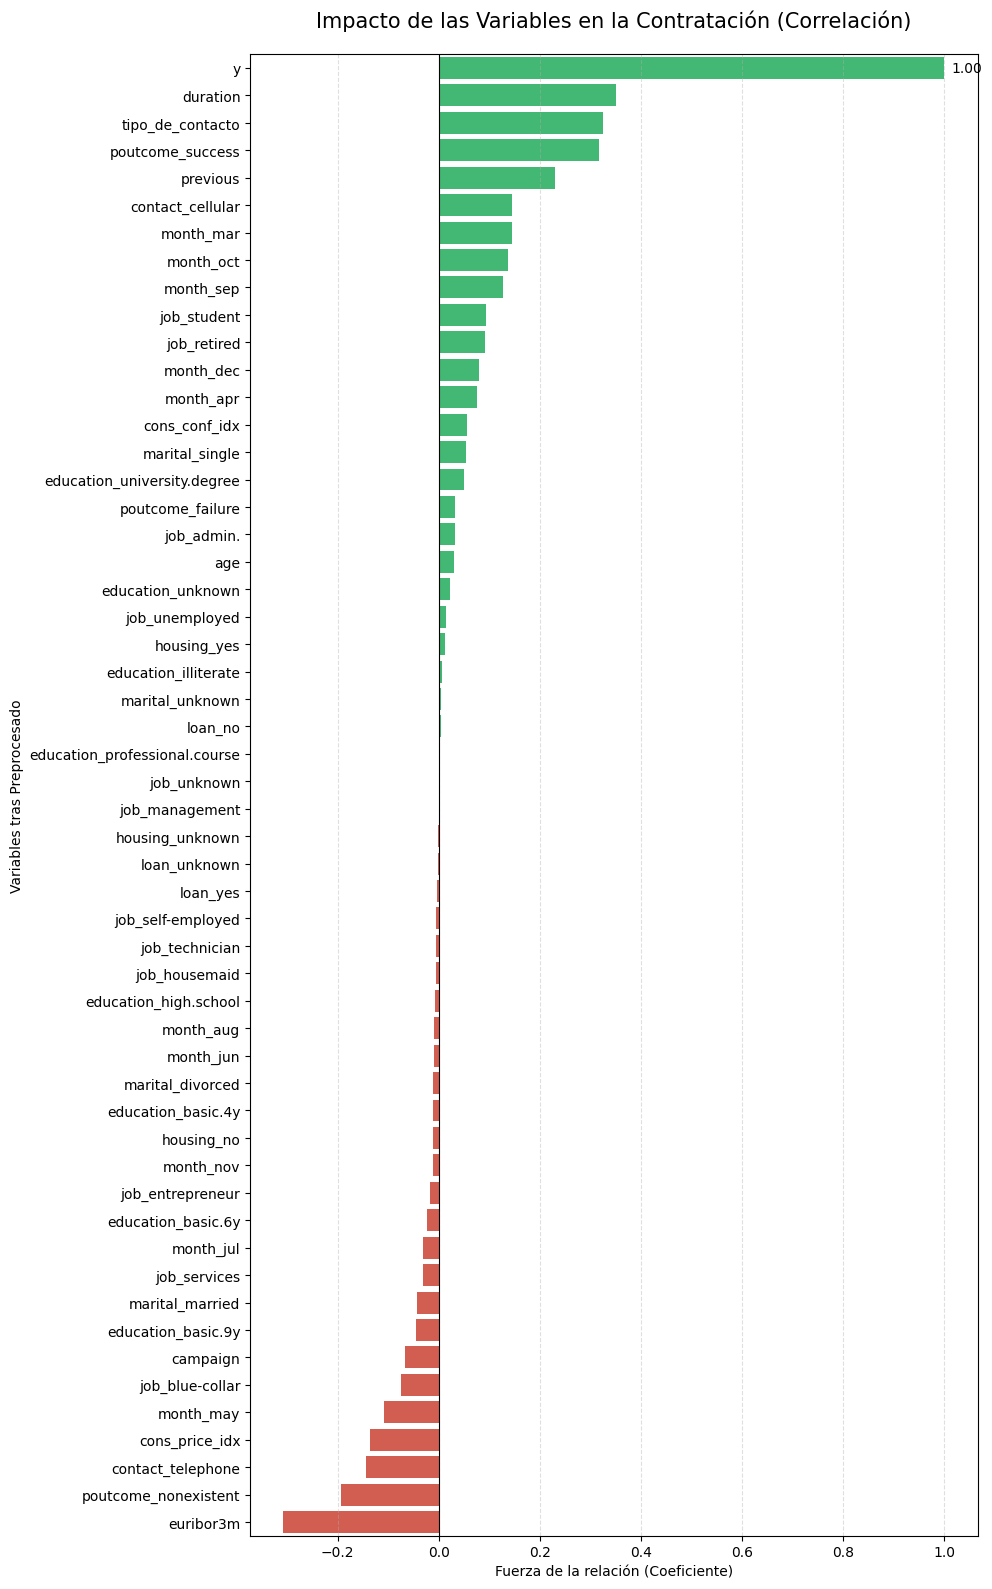

In [34]:
correlations = df_prep.corr()['y'].sort_values(ascending=False)
plt.figure(figsize=(10, 16))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in correlations.values]

ax = sb.barplot(x=correlations.values, y=correlations.index, palette=colors)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=5, fontsize=10)

plt.title('Impacto de las Variables en la Contratación (Correlación)', fontsize=15, pad=20)
plt.xlabel('Fuerza de la relación (Coeficiente)')
plt.ylabel('Variables tras Preprocesado')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

- **Se observa que las variables con más relación son `duration`, `tipo_de_contacto`, `poutcome_success`, `previous` y algunos `month`. Esto ya se habia intuido anteriormente en visual EDA.**
- **Variables como `euribor3m`, `poutcome_nonexistent`, `month_may`, `job_blue_collar` presentan menos fuerza de relación**
- **Es importante la variable `poutcome`, ya que dependiendo de si es success o nonexistent cambia totalmente de fuerza positiva a negativa**
- **La nueva variable generada derivada de `pdays` es una variable con mucha importancia**

## 4. Creación del modelo y división del dataset

Dividimos el dataset de entrenamiento para posteriormente empezar el entrenamiento.

In [35]:
# 1. Definimos la matriz de características (X) y el vector objetivo (y)
X = df_prep.drop('y', axis=1)
y = df_prep['y']

# 2. Dividimos el dataset
# random_state=42 asegura que si ejecutas el código de nuevo, la división sea igual.
# stratify=y es MUY IMPORTANTE: mantiene la proporción de 'Si' y 'No' en ambos conjuntos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Verificamos las dimensiones
print(f"Registros totales: {len(df_prep)}")
print(f"Registros para entrenamiento (X_train): {X_train.shape[0]}")
print(f"Registros para validación (X_val): {X_test.shape[0]}")
print(f"Número de variables/columnas (features): {X_train.shape[1]}")

Registros totales: 41188
Registros para entrenamiento (X_train): 32950
Registros para validación (X_val): 8238
Número de variables/columnas (features): 53


Generamos los 3 modelos que se utilizaran en el proyecto.

### 4.1 Regresión Logística

Se genera el modelo de regresión logística.

In [47]:
model_lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

### 4.2 KNN

Primeramente se calcula cual es el mejor "k" o número de vecinos.

([<matplotlib.axis.XTick at 0x269f2b520d0>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30')])

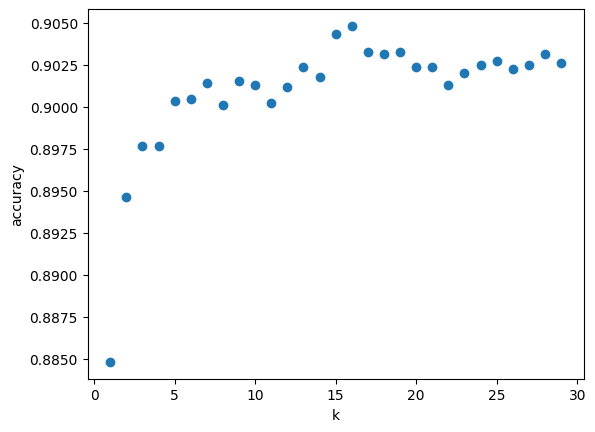

In [61]:
k_range = range(1, 30)
scores = []
for k in k_range:
      knn = KNeighborsClassifier(n_neighbors = k)
      knn.fit(X_train, y_train)
      scores.append(knn.score(X_test, y_test))
plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy')
plt.scatter(k_range, scores)
plt.xticks([0,5,10,15,20,25,30])

Entrenamos el modelo con el "k" seleccionado, en este caso k=16

In [62]:
n_neighbors = 16

knn = KNeighborsClassifier(n_neighbors, weights="distance")

### 4.3 Random Forest

Se genera el modelo de Random Forest.

In [92]:
model_rf = RandomForestClassifier(n_estimators=100, max_depth=15,class_weight="balanced",random_state=42)

## 5. Entrenamiento

### 5.1 Regresión Logística

Entrenamos el modelo de regresión logística.

In [48]:
model_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

Se muestra el intercept, que es el B0 o punto de partida (sesgo).

In [49]:
model_lr.intercept_

array([-0.44445896])

Se muestra el coef, que son los pesos de cada una de las variables.

In [50]:
model_lr.coef_

array([[-0.04392425,  2.37685974, -0.06740366, -0.0109628 ,  0.06845519,
         0.27440343, -1.39748853,  0.7857763 , -0.09261251, -0.35439226,
        -0.22508743, -0.09083272, -0.18788114,  0.44570276, -0.20510815,
        -0.24514652,  0.45954408, -0.07369671,  0.03792623,  0.1170313 ,
        -0.13560251, -0.09002083, -0.07330162, -0.1156281 , -0.20462436,
        -0.12523353, -0.16918127, -0.16499078,  0.10452834,  0.00266747,
         0.12184476,  0.02043631, -0.13015333, -0.16124183, -0.12315789,
        -0.12651713, -0.16124183, -0.1267941 , -0.27019356, -0.1443595 ,
        -0.30183462, -0.32385262, -0.37018653, -0.03266773, -0.08755583,
         1.84130103, -1.51998167, -0.33003399,  1.09437969, -0.3841208 ,
        -0.75623261, -0.27069058,  0.61237013]])

### 5.2 KNN

In [98]:
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",16
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


[[7133  177]
 [ 620  308]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7310
           1       0.64      0.33      0.44       928

    accuracy                           0.90      8238
   macro avg       0.78      0.65      0.69      8238
weighted avg       0.89      0.90      0.89      8238



### 5.3 Random Forest

In [ ]:
model_rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

--- Matriz de Confusión Random Forest ---
[[6652  658]
 [ 178  750]]

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      7310
           1       0.53      0.81      0.64       928

    accuracy                           0.90      8238
   macro avg       0.75      0.86      0.79      8238
weighted avg       0.92      0.90      0.91      8238



## 6. Análisis de resultados

### 6.1 Regresión Logística

Se muestra el score de el modelo Regresión Logística sobre los datos de X_test e y_test.

In [95]:
model_lr.score(X_test,y_test)

0.8606457878125758

Se genera la matriz de confusión y un reporte para ver las métricas.

In [103]:
lr_pred = model_lr.predict(X_test)

# Matriz y Reporte
print("--- Matriz de Confusión ---")
print(confusion_matrix(y_test, lr_pred))
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, lr_pred))

--- Matriz de Confusión ---
[[6252 1058]
 [  90  838]]

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.44      0.90      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.88      0.75      8238
weighted avg       0.92      0.86      0.88      8238



**Análisis:**
- **El 86% de las predicciones totales son correctas (accuracy)**
- **El modelo detecta al 90% de clientes que realmente contratarán (recall clase 1)**
- **De cada 100 posibles ventas, 44 se materializan en una suscripción (precisión clase 1)**
- **Hay muchos falsos positivos, clientes marcados como interesados pero que rechazaron la oferta, esto representa el "coste de oportunidad" del modelo**
- **Regresion Logistica da bastante buenos resultados**

### 6.2 KNN

Se muestra el score de el modelo KNN sobre los datos de X_test e y_test.

In [101]:
knn.score(X_test,y_test)

0.9032532168001942

Se genera la matriz de confusión y un reporte para ver las métricas.

In [102]:
pred = knn.predict(X_test)

# Matriz y Reporte
print("--- Matriz de Confusión ---")
print(confusion_matrix(y_test, pred))
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, pred))

--- Matriz de Confusión ---
[[7133  177]
 [ 620  308]]

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7310
           1       0.64      0.33      0.44       928

    accuracy                           0.90      8238
   macro avg       0.78      0.65      0.69      8238
weighted avg       0.89      0.90      0.89      8238



**Análisis:**
- **El 90% de las predicciones totales son correctas (accuracy)**
- **El modelo detecta a 1 de cada 3 de clientes que realmente contratarán (recall clase 1), esto representa una deficiencia crítica del modelo**
- **De cada 100 posibles ventas, 64 se materializan en una suscripción (precisión clase 1), sin embargo este valor que a priori parece positivo se debe a que el modelo no suele intentar predecir que si (620 falsos negativos vs 308 verdaderos positivos)**
- **El rendimiento real es de un 44% debido al gran volumen de "noes", esto se refleja en el f1-score de la clase 1**
- **Hay muchos falsos negativos, clientes marcados como no interesados pero que si lo estaban, esto es algo muy grave que indica la ineficiencia del modelo**
- **KNN no es un modelo útil en nuestro caso**

### 6.3 Random Forest

Se muestra el score de el modelo Random Forest sobre los datos de X_test e y_test.

In [106]:
model_rf.score(X_test,y_test)

0.8985190580237922

Se genera la matriz de confusión y un reporte para ver las métricas.

In [107]:
y_pred_rf = model_rf.predict(X_test)
print("--- Matriz de Confusión Random Forest ---")
print(confusion_matrix(y_test, y_pred_rf))
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred_rf))

--- Matriz de Confusión Random Forest ---
[[6652  658]
 [ 178  750]]

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      7310
           1       0.53      0.81      0.64       928

    accuracy                           0.90      8238
   macro avg       0.75      0.86      0.79      8238
weighted avg       0.92      0.90      0.91      8238



**Análisis:**
- **El 90% de las predicciones totales son correctas (accuracy)**
- **El modelo detecta al 81% de clientes que realmente contratarán (recall clase 1)**
- **De cada 100 posibles ventas, 53 se materializan en una suscripción (precisión clase 1)**
- **Es el modelo con mejor proporción de precisión y recall, el f1-score de la clase 1 es de 0.64**
- **Random Forest es de los 3 el modelo con mejores resultados**

## 7. Realización de predicciones

### 7.1 Regresión Logística

In [108]:
prob_threshold = 0.5

prob_df=pd.DataFrame(model_lr.predict_proba(df_test_prep[:10]),columns=['Prob of NO','Prob of YES'])
prob_df['Decision']=(prob_df['Prob of YES']>prob_threshold).apply(int)
prob_df



,Prob of NO,Prob of YES,Decision
0,0.315175,0.684825,1
1,0.890203,0.109797,0
2,0.878379,0.121621,0
3,0.999844,0.000156,0
4,0.993666,0.006334,0
5,0.663607,0.336393,0
6,0.109126,0.890874,1
7,0.997249,0.002751,0
8,0.995411,0.004589,0
9,0.981434,0.018566,0


**El modelo predice con bastante seguridad los resultados, es un buen modelo para nuestro caso**

### 7.2 KNN

In [113]:
prob_threshold = 0.5

prob_df=pd.DataFrame(knn.predict_proba(df_test_prep[:10]),columns=['Prob of NO','Prob of YES'])
prob_df['Decision'] = (prob_df['Prob of YES'] > prob_threshold).astype(int)
prob_df



,Prob of NO,Prob of YES,Decision
0,0.838491,0.161509,0
1,0.976693,0.023307,0
2,1.000000,0.000000,0
3,1.000000,0.000000,0
4,1.000000,0.000000,0
5,0.818606,0.181394,0
6,0.820338,0.179662,0
7,1.000000,0.000000,0
8,1.000000,0.000000,0
9,1.000000,0.000000,0


**Como ya se vio en las métricas anteriores, es un muy mal modelo, esta muy sesgado, esto se debe al: número de features, el desbalanceo de clases y los outliers.**

### 7.3 Random Forest

In [114]:
prob_threshold = 0.5

prob_df=pd.DataFrame(model_rf.predict_proba(df_test_prep[:10]),columns=['Prob of NO','Prob of YES'])
prob_df['Decision']=(prob_df['Prob of YES']>prob_threshold).apply(int)
prob_df

,Prob of NO,Prob of YES,Decision
0,0.441765,0.558235,1
1,0.964198,0.035802,0
2,0.954371,0.045629,0
3,0.989121,0.010879,0
4,0.964113,0.035887,0
5,0.865313,0.134687,0
6,0.223521,0.776479,1
7,0.968459,0.031541,0
8,0.977790,0.022210,0
9,0.982216,0.017784,0


**Random forest da muy buenos resultados, coincide con regresión logística en la decisión del target**

## 8. Visualización

Se genera una gráfica que muestra que modelo es más rentable. Basandose en el recall y la precision.

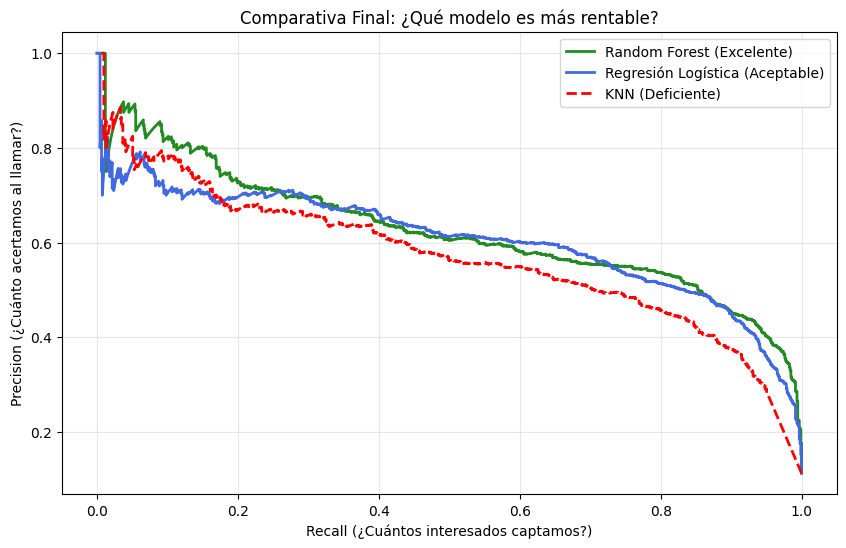

In [126]:
p_rf, r_rf, _ = precision_recall_curve(y_test, model_rf.predict_proba(X_test)[:, 1])
p_lr, r_lr, _ = precision_recall_curve(y_test, model_lr.predict_proba(X_test)[:, 1])
p_knn, r_knn, _ = precision_recall_curve(y_test, knn.predict_proba(X_test)[:, 1])


plt.figure(figsize=(10, 6))


plt.plot(r_rf, p_rf, label='Random Forest (Excelente)', color='forestgreen', linewidth=2)
plt.plot(r_lr, p_lr, label='Regresión Logística (Aceptable)', color='royalblue', linewidth=2)
plt.plot(r_knn, p_knn, label='KNN (Deficiente)', color='red', linestyle='--', linewidth=2)

plt.xlabel('Recall (¿Cuántos interesados captamos?)')
plt.ylabel('Precision (¿Cuánto acertamos al llamar?)')
plt.title('Comparativa Final: ¿Qué modelo es más rentable?')
plt.legend(loc='best')
plt.grid(alpha=0.3)

plt.show()

Se genera una grafica que muestra la curva Precision-Recall

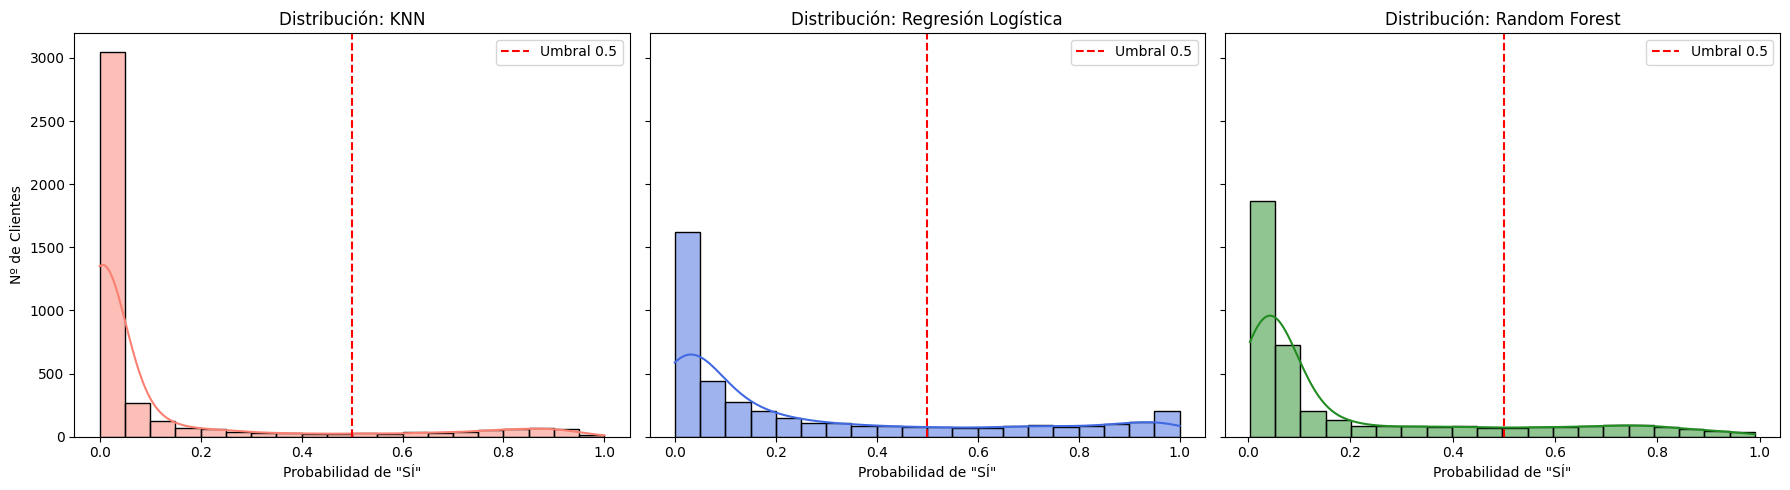

In [127]:
prob_knn = knn.predict_proba(df_test_prep)[:, 1]
prob_lr = model_lr.predict_proba(df_test_prep)[:, 1]
prob_rf = model_rf.predict_proba(df_test_prep)[:, 1]


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
modelos = ['KNN', 'Regresión Logística', 'Random Forest']
probabilidades = [prob_knn, prob_lr, prob_rf]
colores = ['salmon', 'royalblue', 'forestgreen']


for i, ax in enumerate(axes):
    sb.histplot(probabilidades[i], bins=20, kde=True, ax=ax, color=colores[i])
    ax.axvline(x=0.5, color='red', linestyle='--', label='Umbral 0.5')
    ax.set_title(f'Distribución: {modelos[i]}')
    ax.set_xlabel('Probabilidad de "SÍ"')
    ax.set_ylabel('Nº de Clientes')
    ax.legend()

plt.tight_layout()
plt.show()

Se generan las gráficas ROC, que es el estandar de clasificación binaria, mide la capacidad del modelo para distinguir entre las dos clases (No y Si)

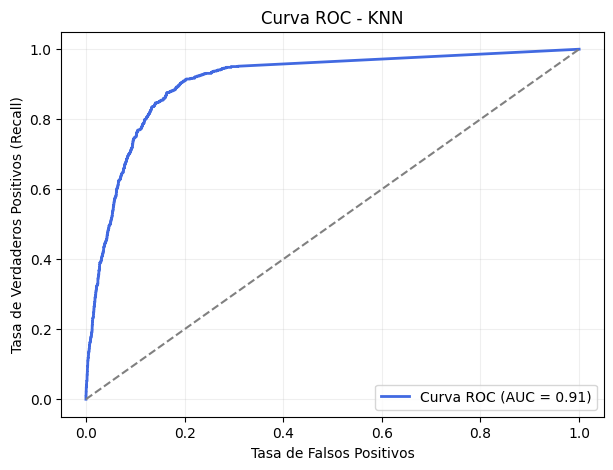

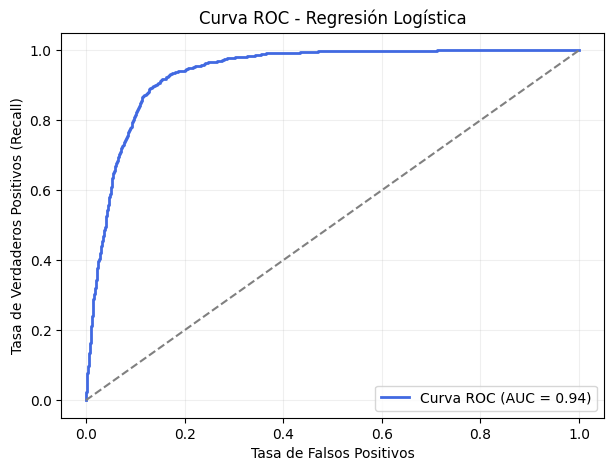

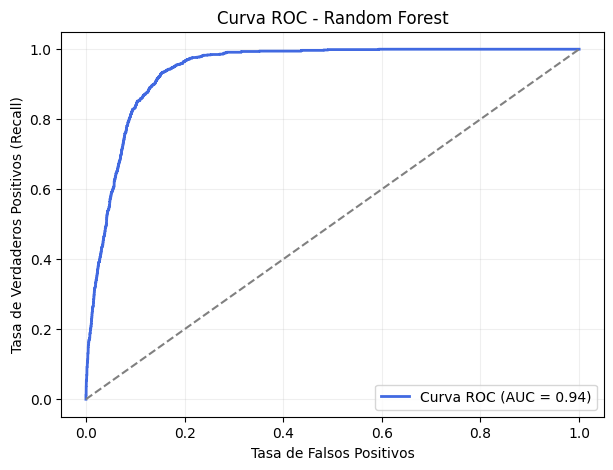

In [ ]:


modelos = [
    ('KNN', knn, 'royalblue'),
    ('Regresión Logística', model_lr, 'royalblue'),
    ('Random Forest', model_rf, 'royalblue')
]

for nombre, modelo, color in modelos:

    probs = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color=color, lw=2, label=f'Curva ROC (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    

    plt.title(f'Curva ROC - {nombre}')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)
    plt.show()